### Logistic Regression – Concept Overview

Logistic Regression is a supervised classification algorithm used for binary classification problems.

Although it’s called regression, it is used for classification because it predicts probabilities.

### Math Behind Logistic Regression (Core Theory)
Step 1: Linear Model

We start similarly to Linear Regression:

𝑧=𝑤𝑇𝑥+𝑏
z=w
T
x+b

Where:
𝑤  w = weights vector
𝑥  x = input features
𝑏  b = bias
𝑧  z = linear combination

Step 2: Sigmoid Function

To convert 𝑧 into a probability:

        𝜎(𝑧)=1+𝑒−𝑧σ(z)=1+e−z

This ensures:
         0≤𝜎(𝑧)≤1

So,
         𝑦^=𝜎(𝑤𝑇𝑥+𝑏)

### 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2. Create Dataset

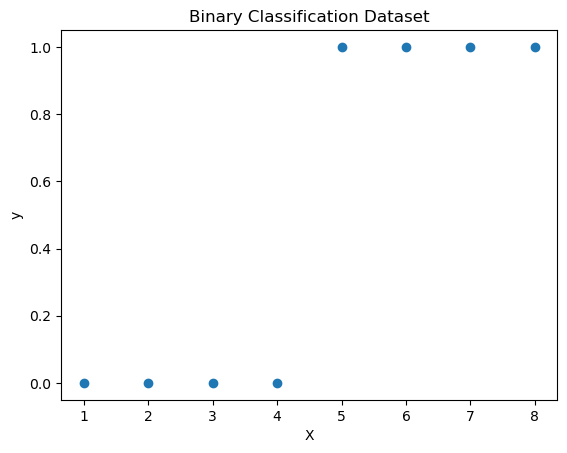

In [5]:
# Simple binary classification dataset
X = np.array([1,2,3,4,5,6,7,8]).reshape(-1,1)
y = np.array([0,0,0,0,1,1,1,1])

# Plot dataset
plt.scatter(X, y)
plt.title("Binary Classification Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

- The dataset shows two classes (0 and 1).
- The goal is to classify data points into these categories.

### 3. Math Behind Logistic Regression

#### Model Equation

z = mX + b
ŷ = sigmoid(z)

#### Cost function(Log Loss)

Loss = - (1/n) * Σ [ y log(ŷ) + (1-y) log(1-ŷ) ]

- Sigmoid converts output into probability (0 to 1)
- Logistic Regression is used for classification, not regression

### 4. Initialize Parameters

In [6]:
m = 0
b = 0
learning_rate = 0.01
epochs = 1000
n = len(X)

### 5. Sigmoid Function

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### 6. Gradient Descent

In [8]:
for i in range(epochs):
    z = m * X.flatten() + b
    y_pred = sigmoid(z)
    
    # Gradients
    dm = (1/n) * np.sum((y_pred - y) * X.flatten())
    db = (1/n) * np.sum(y_pred - y)
    
    # Update
    m -= learning_rate * dm
    b -= learning_rate * db
    
    # Print loss
    if i % 100 == 0:
        loss = -np.mean(y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9))
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.6931471785599453
Epoch 100, Loss: 0.586141505574264
Epoch 200, Loss: 0.5586337167380745
Epoch 300, Loss: 0.5335438199868059
Epoch 400, Loss: 0.5106414791334182
Epoch 500, Loss: 0.4897123199495858
Epoch 600, Loss: 0.4705584768074945
Epoch 700, Loss: 0.4529994045098918
Epoch 800, Loss: 0.43687180564372896
Epoch 900, Loss: 0.4220289587302772


- Loss decreases over time, meaning model is learning
- Gradient Descent updates parameters step-by-step

### 7. Prediction

In [9]:
z = m * X + b
probs = sigmoid(z)

predictions = [1 if i > 0.5 else 0 for i in probs]

print("Predictions:", predictions)

Predictions: [0, 0, 0, 1, 1, 1, 1, 1]


- Values above 0.5 are classified as class 1
- Model separates two classes effectively

### 8. Visualization

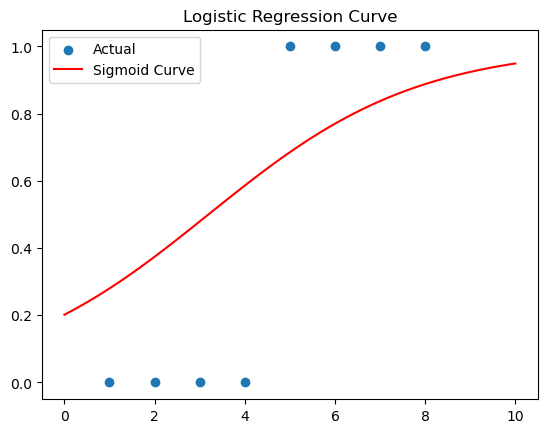

In [10]:
plt.scatter(X, y, label="Actual")

# Smooth curve
x_vals = np.linspace(0,10,100)
y_vals = sigmoid(m*x_vals + b)

plt.plot(x_vals, y_vals, color='red', label="Sigmoid Curve")

plt.legend()
plt.title("Logistic Regression Curve")
plt.show()

- Sigmoid curve clearly separates the two classes
- Shows probability transition from 0 to 1

### 9. Scikit learn Implementation

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

sk_preds = model.predict(X)

print("Sklearn Predictions:", sk_preds)

Sklearn Predictions: [0 0 0 0 1 1 1 1]


### 11. Comparison

- Results are very similar → confirms correctness
- From-scratch implementation is working properly

### Learnings

- Logistic Regression is used for classification
- Sigmoid function converts output into probability
- Gradient Descent minimizes loss
- Learning rate controls convergence